<a href="https://colab.research.google.com/github/simraa2302/resume-scanner/blob/main/resumescanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q spacy pdfminer.six openpyxl matplotlib
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 65.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving resume (1).pdf to resume (1) (1).pdf
Saving Sreemen Kumar Resume.pdf to Sreemen Kumar Resume (1).pdf
Saving simraa resume (2).pdf to simraa resume (2) (1).pdf
Saving YasminResume_20241027_191429_0000.pdf to YasminResume_20241027_191429_0000 (1).pdf
Saving RESUME1.pdf to RESUME1 (1).pdf
Saving SREELEKHA RESUME.pdf to SREELEKHA RESUME (1).pdf
Saving Veshal Resume 2025.pdf to Veshal Resume 2025 (1).pdf


In [ ]:
from pdfminer.high_level import extract_text
import os

# Extract text from each uploaded PDF
resumes = {}
for file in uploaded.keys():
    text = extract_text(file)
    resumes[file] = text



In [ ]:
preferred_skills = [
    'python', 'machine learning', 'data analysis',
    'sql', 'communication', 'leadership', 'django',
    'flask', 'nlp', 'deep learning'
]



In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

resume_scores = {}

for name, content in resumes.items():
    doc = nlp(content.lower())
    words = [token.text for token in doc if token.is_alpha]
    skill_matches = set(words) & set(preferred_skills)
    score = len(skill_matches)
    resume_scores[name] = {"score": score, "skills": list(skill_matches)}


In [ ]:
sorted_resumes = sorted(resume_scores.items(), key=lambda x: x[1]['score'], reverse=True)

print("🏆 Top 3 Candidates:")
for i, (name, data) in enumerate(sorted_resumes[:3]):
    print(f"{i+1}. {name} - Score: {data['score']} - Skills: {', '.join(data['skills'])}")



🏆 Top 3 Candidates:
1. simraa resume (2) (1).pdf - Score: 5 - Skills: sql, python, leadership, nlp, communication
2. SREELEKHA RESUME (1).pdf - Score: 4 - Skills: sql, leadership, python, communication
3. Veshal Resume 2025 (1).pdf - Score: 4 - Skills: sql, leadership, python, communication


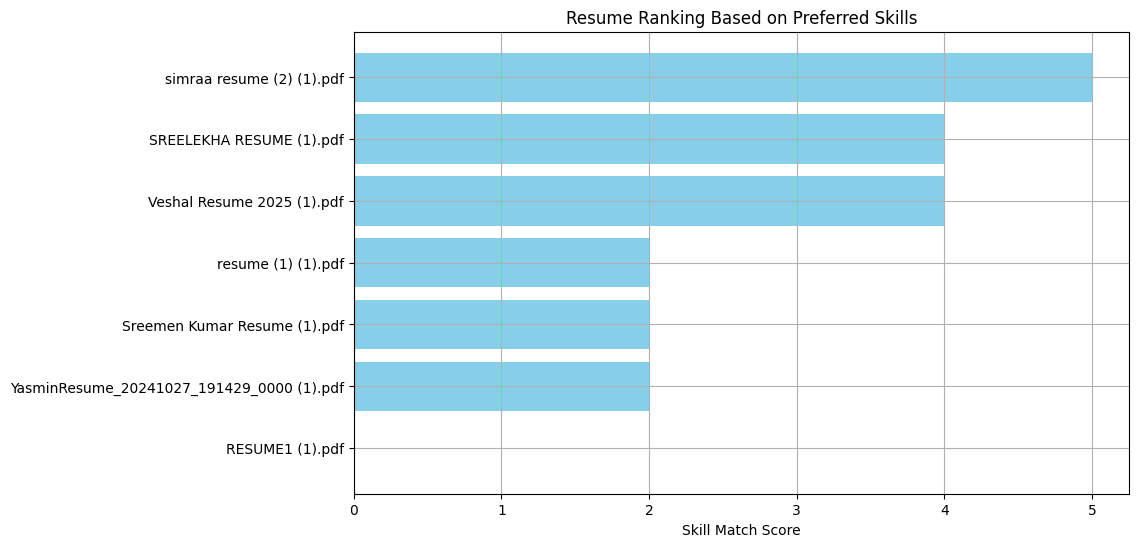

In [ ]:
import matplotlib.pyplot as plt

names = [x[0] for x in sorted_resumes]
scores = [x[1]['score'] for x in sorted_resumes]

plt.figure(figsize=(10,6))
plt.barh(names[::-1], scores[::-1], color='skyblue')
plt.xlabel("Skill Match Score")
plt.title("Resume Ranking Based on Preferred Skills")
plt.grid(True)
plt.show()


In [ ]:
# --- Define skills for two different roles ---
role1_name = "Data Analyst"
role2_name = "AI Engineer"

role1_skills = {"excel", "data visualization", "power bi", "tableau", "sql", "statistics", "python"}
role2_skills = {"python", "deep learning", "machine learning", "nlp", "pytorch", "tensorflow", "ai", "cv"}

# --- Analyze resumes for both roles ---
role1_scores = {}
role2_scores = {}

for filename, text in resumes.items():
    words = set(text.lower().split())
    role1_match_count = len(words & role1_skills)
    role2_match_count = len(words & role2_skills)

    role1_scores[filename] = role1_match_count
    role2_scores[filename] = role2_match_count

# --- Sort and display top 3 for each role ---
sorted_role1 = sorted(role1_scores.items(), key=lambda x: x[1], reverse=True)
sorted_role2 = sorted(role2_scores.items(), key=lambda x: x[1], reverse=True)

print(f"\n🎯 Top 3 candidates for {role1_name}:")
for i, (filename, score) in enumerate(sorted_role1[:3], 1):
    print(f"{i}. {filename} - Score: {score}")

print(f"\n🎯 Top 3 candidates for {role2_name}:")
for i, (filename, score) in enumerate(sorted_role2[:3], 1):
    print(f"{i}. {filename} - Score: {score}")


🎯 Top 3 candidates for Data Analyst:
1. YasminResume_20241027_191429_0000 (1).pdf - Score: 3
2. Sreemen Kumar Resume (1).pdf - Score: 2
3. SREELEKHA RESUME (1).pdf - Score: 2

🎯 Top 3 candidates for AI Engineer:
1. resume (1) (1).pdf - Score: 2
2. simraa resume (2) (1).pdf - Score: 2
3. YasminResume_20241027_191429_0000 (1).pdf - Score: 2


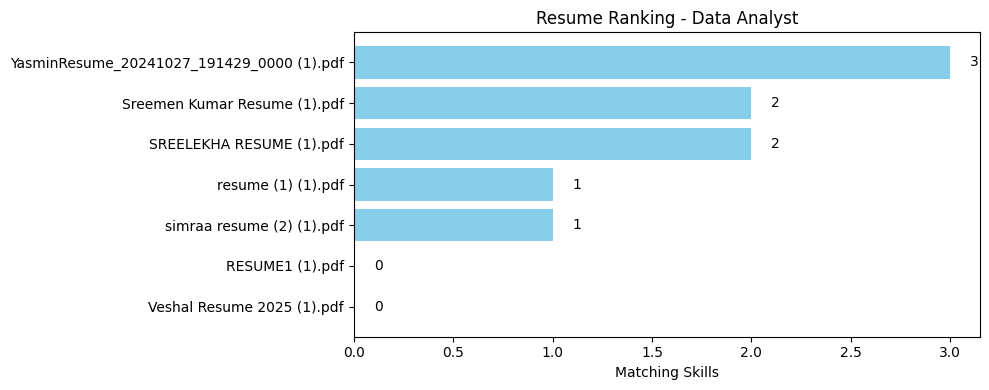

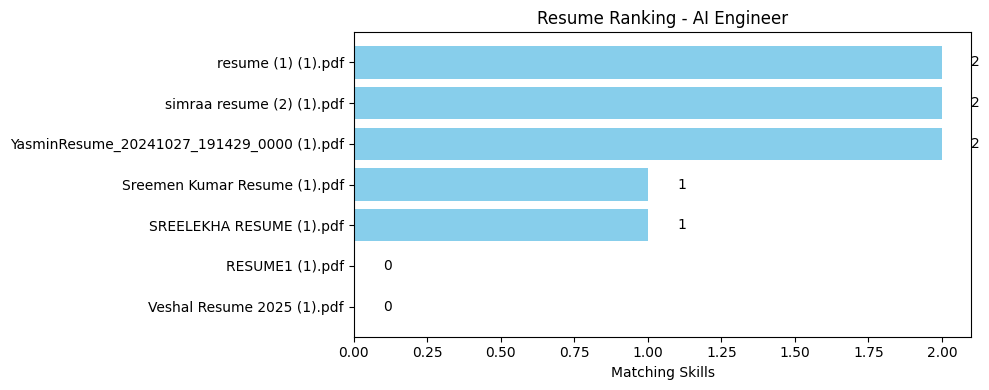

In [ ]:
# --- Visualization using matplotlib ---
import matplotlib.pyplot as plt

def plot_scores(score_dict, role_name):
    names = list(score_dict.keys())
    scores = list(score_dict.values())

    plt.figure(figsize=(10, 4))
    bars = plt.barh(names, scores, color='skyblue')
    plt.xlabel("Matching Skills")
    plt.title(f"Resume Ranking - {role_name}")
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{width}', va='center')

    plt.tight_layout()
    plt.show()

# Plot charts
plot_scores(dict(sorted_role1[:10]), role1_name)
plot_scores(dict(sorted_role2[:10]), role2_name)
